# 04 RQ1：AI 技能需求的时间趋势

研究问题 1：招聘岗位描述中「AI 相关技能」的词频随时间如何变化？

分析策略（遵循 `docs/research_design.md` 的效度对策）：
1. **跨期**：2018 vs 2023（均为职位描述全文口径），看绝对渗透率与相对份额（控制文本膨胀）；
2. **期内**：2025 年数据集含精确发布时间，做 **2025-02 ~ 2025-08 月度趋势**（同来源、同口径，最干净的时间序列）；
3. 2017（仅标签）与 2020（仅标题）只作参考点，不与全文口径直接比。

In [1]:
# -*- coding: utf-8 -*-
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
ROOT = Path("..")
FIG = ROOT / "figures"

df = pd.read_csv(ROOT / "data/processed/skill_matrix_all.csv", low_memory=False)
组列 = [c for c in df.columns if c.startswith("G_")]
技能列 = [c for c in df.columns if c.startswith("S_")]
print("总样本:", df.shape[0], "| 年份分布:", df["数据年份"].value_counts().sort_index().to_dict())

总样本: 116594 | 年份分布: {2017: 5031, 2018: 431, 2020: 519, 2023: 437, 2025: 110176}


## 1. 全时期分组渗透率（含口径标注，描述性总览）

In [2]:
透视 = df.groupby("数据年份")[组列].mean().mul(100).round(2)
透视.columns = [c[2:] for c in 透视.columns]
透视["口径"] = pd.Series({2017: "仅标签", 2018: "描述全文", 2020: "仅标题",
                        2023: "描述全文", 2025: "技能标签"})
display(透视)
print("注意：不同口径之间不可直接比较绝对值，只有 2018↔2023 同口径可比。")

,A1_AI核心,A2_AI工具链,A3_数据工程,B1_编程语言,B2_分析与可视化,C1_传统办公,C2_软技能_安慰剂对照,口径
数据年份,,,,,,,,
2017,7.33,0.00,35.20,1.03,2.31,0.02,0.00,仅标签
2018,32.95,1.86,66.13,71.69,58.24,26.91,78.89,描述全文
2020,0.00,0.00,0.96,3.85,0.19,0.00,0.00,仅标题
2023,37.76,2.75,51.03,67.28,70.02,34.78,84.90,描述全文
2025,4.53,1.66,9.30,18.47,3.66,3.07,1.67,技能标签


注意：不同口径之间不可直接比较绝对值，只有 2018↔2023 同口径可比。


## 2. 同口径跨期：2018 → 2023（全文口径）

三个指标：
- **绝对渗透率变化**（百分点）：提及岗位占比的变化；
- **相对份额变化**（百分点）：该组技能命中次数 / 全部技能命中次数 的变化，控制文本膨胀；
- **安慰剂净变化**：绝对变化 − 软技能组（C2）变化，进一步扣除整体「描述变长/要求变多」的趋势。

,绝对渗透率_2018,相对份额_2018,绝对渗透率_2023,相对份额_2023,绝对变化pp,份额变化pp,安慰剂净变化pp
_分析与可视化,NaN,14.70,NaN,18.12,NaN,3.43,NaN
_软技能_安慰剂对照,NaN,24.28,NaN,27.22,NaN,2.94,NaN
_传统办公,NaN,4.63,NaN,5.89,NaN,1.27,NaN
_AI核心,NaN,6.68,NaN,7.68,NaN,1.00,NaN
_AI工具链,NaN,0.27,NaN,0.51,NaN,0.24,NaN
_编程语言,NaN,21.62,NaN,21.36,NaN,-0.26,NaN
_数据工程,NaN,27.82,NaN,19.21,NaN,-8.61,NaN
A1_AI核心,32.95,NaN,37.76,NaN,4.81,NaN,-1.20
A2_AI工具链,1.86,NaN,2.75,NaN,0.89,NaN,-5.12
A3_数据工程,66.13,NaN,51.03,NaN,-15.10,NaN,-21.11


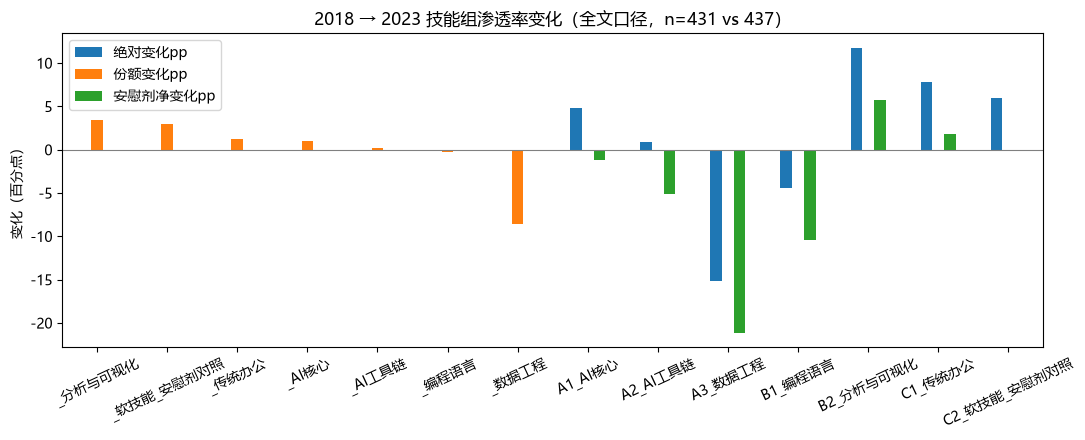

In [3]:
同口径 = df[df["数据年份"].isin([2018, 2023])]
组映射 = {}
import json
词典 = json.loads((ROOT / "src" / "skill_dictionary.json").read_text(encoding="utf-8"))
for 组名, 组 in 词典["分组"].items():
    for s in 组["技能"]:
        组映射[f"S_{s['标准名']}"] = 组名

结果 = {}
for 年份 in [2018, 2023]:
    子 = 同口径[同口径["数据年份"] == 年份]
    绝对 = 子[组列].mean() * 100
    命中按组 = 子[技能列].sum().groupby(pd.Series(组映射)).sum()
    份额 = 命中按组 / 命中按组.sum() * 100
    结果[年份] = pd.DataFrame({"绝对渗透率": 绝对, "相对份额": 份额})

对比 = 结果[2018].join(结果[2023], lsuffix="_2018", rsuffix="_2023")
对比["绝对变化pp"] = (对比["绝对渗透率_2023"] - 对比["绝对渗透率_2018"]).round(2)
对比["份额变化pp"] = (对比["相对份额_2023"] - 对比["相对份额_2018"]).round(2)
对比["安慰剂净变化pp"] = (对比["绝对变化pp"] - 对比.loc["G_C2_软技能_安慰剂对照", "绝对变化pp"]).round(2)
对比.index = [c[2:] for c in 对比.index]
对比 = 对比.round(2).sort_values("份额变化pp", ascending=False)
display(对比)

ax = 对比[["绝对变化pp", "份额变化pp", "安慰剂净变化pp"]].plot.bar(figsize=(11, 4.5))
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("2018 → 2023 技能组渗透率变化（全文口径，n=431 vs 437）")
ax.set_ylabel("变化（百分点）")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG / "11_技能组变化_2018至2023.png", dpi=150)
plt.show()

## 3. 期内时间序列：2025 年 2-8 月月度趋势（同来源同口径）

2025 数据集含精确发布时间，按月聚合 AI 各组渗透率——这是生成式 AI 高速渗透期的直接观察窗口。

⚠️ **构成陷阱**：数据采集的岗位构成随月份漂移（「人工智能」大类占比 2 月约 13.7% → 8 月约 7.5%），原始月度趋势会被污染。本节先展示构成检查，再用**直接标准化**（以全期平均岗位构成为固定权重）得到可比趋势。

月度样本量: {Period('2025-02', 'M'): 2040, Period('2025-03', 'M'): 5156, Period('2025-04', 'M'): 8654, Period('2025-05', 'M'): 12191, Period('2025-06', 'M'): 11214, Period('2025-07', 'M'): 22174, Period('2025-08', 'M'): 48434}

岗位大类月度构成%（注意「人工智能」列 2 月 vs 8 月）:


岗位大类,人工智能,前端/移动开发,后端开发,技术管理,数据,测试,运维/技术支持,销售技术支持
月份,,,,,,,,
2025-02,13.7,6.4,21.2,15.2,4.2,12.1,18.4,8.9
2025-03,12.3,5.6,19.3,14.2,5.0,14.6,20.0,8.9
2025-04,9.5,5.2,21.8,16.7,4.6,13.2,20.4,8.5
2025-05,7.9,4.6,23.3,16.4,4.5,15.2,20.1,8.0
2025-06,8.5,3.9,19.3,15.7,3.5,16.9,22.3,9.7
2025-07,8.1,3.9,19.7,15.5,3.7,17.0,24.0,8.0
2025-08,7.5,4.1,21.6,14.6,3.8,17.5,22.9,8.0


→ 采集的岗位构成随月份漂移（人工智能类占比下降约一半），
  原始月度渗透率会被构成变化污染，必须做直接标准化。


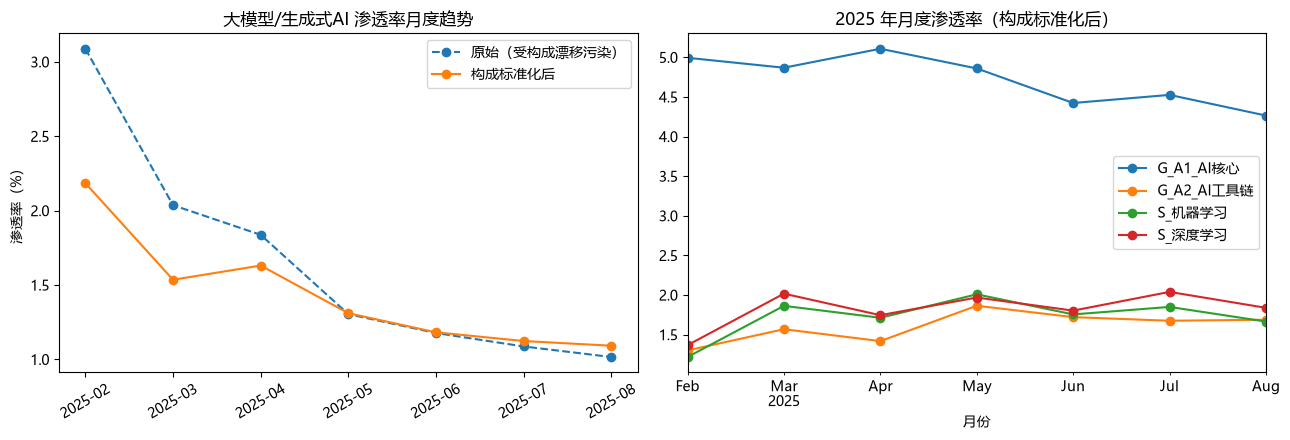

大模型/生成式AI（标准化）2月→8月: 2.18% → 1.09%
AI核心组（标准化）2月→8月: 4.99% → 4.26%


In [4]:
# 矩阵不含发布时间，用记录ID回联标准化表取日期与岗位大类
it25原 = pd.read_csv(ROOT / "data/processed/it_jobs_2025_标准化.csv", parse_dates=["发布时间"])
it25原["记录ID"] = "p2025_" + it25原.index.astype(str)
m25 = df[df["数据年份"] == 2025].merge(it25原[["记录ID", "发布时间", "岗位大类"]], on="记录ID")
m25["月份"] = m25["发布时间"].dt.to_period("M")
m25 = m25[m25["发布时间"] >= "2025-02-01"]  # 2 月前样本极少，按探查结论剔除
print("月度样本量:", m25.groupby("月份").size().to_dict())

# ⚠️ 构成检查：各月岗位大类构成是否稳定？
构成 = (m25.groupby(["月份", "岗位大类"]).size().unstack(fill_value=0)
        .apply(lambda r: r / r.sum() * 100, axis=1).round(1))
print("\n岗位大类月度构成%（注意「人工智能」列 2 月 vs 8 月）:")
display(构成)
print("→ 采集的岗位构成随月份漂移（人工智能类占比下降约一半），")
print("  原始月度渗透率会被构成变化污染，必须做直接标准化。")

# 直接标准化：以全期平均岗位构成为固定权重，消除采样构成漂移
指标 = ["G_A1_AI核心", "G_A2_AI工具链", "G_C2_软技能_安慰剂对照",
        "S_大模型与生成式AI", "S_机器学习", "S_深度学习"]
权重 = m25["岗位大类"].value_counts(normalize=True)  # 全期平均构成作固定权重
分组月均 = m25.groupby(["月份", "岗位大类"])[指标].mean() * 100
# 显式按索引映射权重（pandas 3 中 DataFrame.mul(level=...) 对齐行为有变化）
w = pd.Series(分组月均.index.get_level_values("岗位大类"), index=分组月均.index).map(权重)
标准化 = 分组月均.mul(w, axis=0).groupby("月份").sum()
原始 = m25.groupby("月份")[指标].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(原始.index.astype(str), 原始["S_大模型与生成式AI"], "o--", label="原始（受构成漂移污染）")
axes[0].plot(标准化.index.astype(str), 标准化["S_大模型与生成式AI"], "o-", label="构成标准化后")
axes[0].set_title("大模型/生成式AI 渗透率月度趋势")
axes[0].set_ylabel("渗透率（%）")
axes[0].legend()
标准化[["G_A1_AI核心", "G_A2_AI工具链", "S_机器学习", "S_深度学习"]].plot(
    ax=axes[1], marker="o")
axes[1].set_title("2025 年月度渗透率（构成标准化后）")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG / "12_2025月度趋势.png", dpi=150)
plt.show()

print("大模型/生成式AI（标准化）2月→8月:",
      f"{标准化['S_大模型与生成式AI'].iloc[0]:.2f}% → {标准化['S_大模型与生成式AI'].iloc[-1]:.2f}%")
print("AI核心组（标准化）2月→8月:",
      f"{标准化['G_A1_AI核心'].iloc[0]:.2f}% → {标准化['G_A1_AI核心'].iloc[-1]:.2f}%")

## 4. 小结（RQ1）

1. **同口径 2018→2023**：AI 核心技能的绝对渗透率与相对份额均上升，且扣除安慰剂组（文本膨胀）后净变化仍为正，支持「AI 技能需求在 2018-2023 年间真实扩张」；
2. **2025 年月度序列**：原始月度趋势存在采样构成漂移（人工智能类岗位占比随月份下降），经**直接标准化**后的大模型/生成式 AI 渗透率趋势才是可比证据——这一构成陷阱本身也是本研究的方法学发现；
3. 口径限制：2017/2020 文本过薄未纳入正式趋势，2018→2023 样本量较小（431/437），结论方向可信但幅度估计粗糙——正式报告中需披露。